In [475]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
from  numpy.linalg import inv 







A = 5* np.eye(4) 
#A[0,1] += 0.1
#A[1,0] += 0.1
#A[1,3] += 0.1
A[1,1] = 2


ValueError: x and y can be no greater than 2D, but have shapes (1000, 4, 4) and (1000, 4, 4)

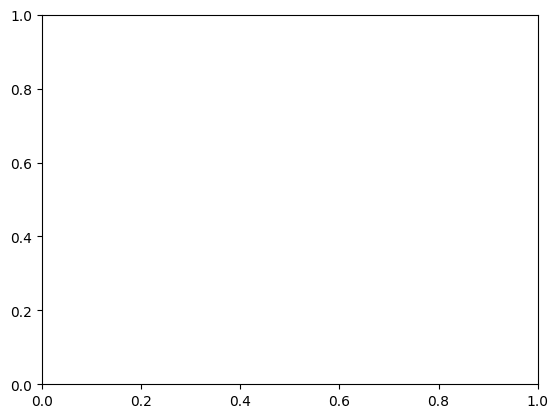

In [497]:



# calc the field of values of A , to do so we multiply A by e^{i*theta}
N= 1000
maxlam = []
Thetas = np.linspace(0, 2* np.pi, N)
for theta in Thetas:
    expithetaA = np.exp(-1j*theta)* A

    # lambda with max real part
    lam , eigs = np.linalg.eig(expithetaA)

    # zstar = eigs * A *eigs.conj()
    zstar =(expithetaA @ eigs.conj()) @ eigs.T
    maxlam.append( zstar )


maxlam = np.array(maxlam)
plt.plot( maxlam.real, maxlam.imag, "-*")
print(maxlam)



















In [ ]:



I =1* np.eye(4) 

A = -1* np.eye(4) 
A[0,1] += 0.1
A[1,0] += 0.1

Lambs, U = np.linalg.eig(A)

exp_Lambs = np.diag(np.exp(Lambs))
exp_A = U@ exp_Lambs @ U.T

print(exp_A)
print(scipy.linalg.expm(A))

In [ ]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
from  numpy.linalg import inv 



In [ ]:

































I =1* np.eye(4) 

A = -1* np.eye(4) 
A[0,1] += 0.1
A[1,0] += 0.1

Lambs, U = np.linalg.eig(A)

exp_Lambs = np.diag(np.exp(Lambs))
exp_A = U@ exp_Lambs @ U.T

print(exp_A)
print(scipy.linalg.expm(A))

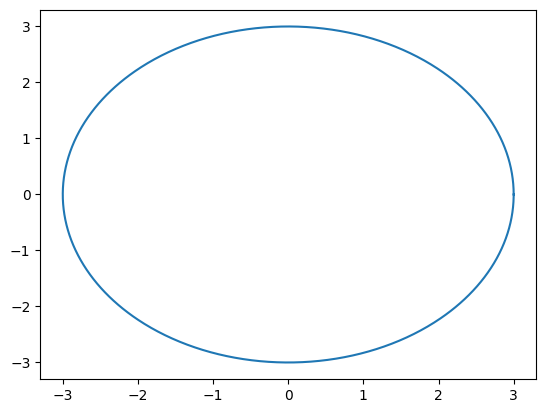

In [415]:
# Now we implement the contour integral for finding the matrix exponential
N = 1000
Theta = np.linspace(0, 2*np.pi, N+1)
dtheta = 2*np.pi / N
# Z = Z(Theta)
Z = 3*np.exp(1j*Theta)
# dZ = dZ(Theta) the actual derivative
dZ =  3*1j*np.exp(1j*Theta)
expA2 = np.zeros((4,4), dtype = np.complex128)
plt.plot( np.real(Z), np.imag(Z))
for z, dz in zip(Z , dZ):
    expA2 +=1/(2*np.pi*1j) * np.exp(z)*  dz*dtheta * inv(z*I-A) 

In [418]:
print(expA2.real)
print(scipy.linalg.expm(A))

[[0.38479395 0.03722613 0.         0.        ]
 [0.03722613 0.38479395 0.         0.        ]
 [0.         0.         0.38294359 0.        ]
 [0.         0.         0.         0.38294359]]
[[0.36972037 0.03684929 0.         0.        ]
 [0.03684929 0.36972037 0.         0.        ]
 [0.         0.         0.36787944 0.        ]
 [0.         0.         0.         0.36787944]]


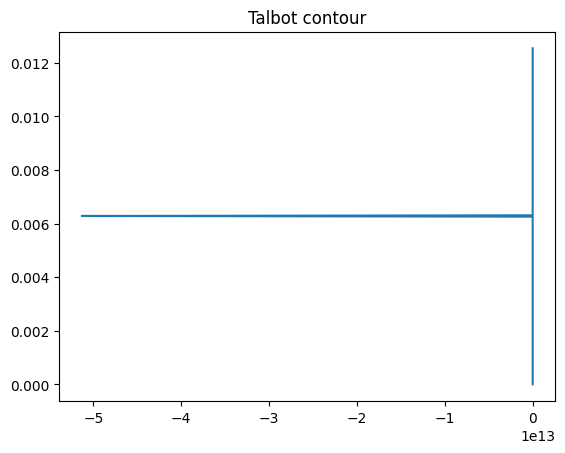

In [435]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import inv

N = 500
k = np.arange(N)

# trapezoidal grid (DO NOT include endpoint)
theta = 2*np.pi * k / N

# Talbot parameters (tunable)
sigma = 0.00001
mu = 1.0/N

# avoid division issues at endpoints
eps = 1e-14
theta_safe = np.where(theta == 0, eps, theta)

# Talbot contour
Z =- sigma + mu * (theta_safe / np.tan(theta_safe) + 1j * theta_safe)

# derivative
dZ = mu * (1/np.tan(theta_safe) - theta_safe/(np.sin(theta_safe)**2) + 1j)

dTheta =1* 2*np.pi / N


expA2 = np.zeros((4,4), dtype=np.complex128)

I = np.eye(A.shape[0])
dtheta = 2*np.pi / N
for z, dz in zip(Z, dZ):
    expA2 += np.exp(z) *inv(z*I - A) * dz 

# final trapezoidal scaling
expA2 *= (1/(2*np.pi*1j)) * (2*np.pi / N)

plt.plot(np.real(Z), np.imag(Z))
plt.title("Talbot contour")
plt.show()

expA2 = expA2.real

In [436]:
print(expA2)
print(scipy.linalg.expm(A) )
print( expA2/scipy.linalg.expm(A) )

[[0.07624636 0.01139889 0.         0.        ]
 [0.01139889 0.07624636 0.         0.        ]
 [0.         0.         4.55108276 0.        ]
 [0.         0.         0.         4.55108276]]
[[0.36972037 0.03684929 0.         0.        ]
 [0.03684929 0.36972037 0.         0.        ]
 [0.         0.         0.36787944 0.        ]
 [0.         0.         0.         0.36787944]]
[[ 0.20622709  0.30933816         nan         nan]
 [ 0.30933816  0.20622709         nan         nan]
 [        nan         nan 12.37112555         nan]
 [        nan         nan         nan 12.37112555]]


In [198]:
from ngsolve import *
from ngsolve.webgui import *
import numpy as np
import time
from ngsolve import bla
mesh = Mesh(unit_square.GenerateMesh(maxh = 0.1))
fes = H1(mesh, order=3, dirichlet = "", complex = True)

u, v = fes.TnT()
a = BilinearForm(fes)
a +=grad(u)*grad(v)*dx

#a = BilinearForm(fes)
#a += 3*u*v*dx


m = BilinearForm(fes)
m += u*v*dx

a.Assemble()
m.Assemble()

f = LinearForm(fes)
f +=1* 100*sin(4*pi*(x*y-0.5))*v*dx
f.Assemble()



X = CF((x, y))
C = CF((0.5, 0.5))
u0 = 10*x*y*sin(2*pi*x)*sin(2*pi*y)*exp(-10*Norm(C-X)**2)
u0 = sin(2*pi*x)*sin(2*pi*y)
Draw(u0, mesh)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

In [199]:
gfu = GridFunction(fes)
gfu.Set(u0)

    Input:
        M, K      FEM matrices
        v         vector
        h         timestep
        N         number of Talbot nodes
    
    rhs = M*v
    
    Choose Talbot scale μ
    
    y = 0
    
    for j = 0,...,N-1
    
        θ = -π + (j+0.5)*(2π/N)
    
        z =
            μ*( θ*cot(θ) + i*θ )
    
        dz =
            μ*( cot(θ)
                - θ*csc(θ)^2
                + i )
    
        Solve:
            (z*M - K)x = rhs
    
        y += exp(-h*z) * dz * x
    
    end
    
    y = y/(N*i)
    
    return Real(y)

In [207]:
M= m.mat 
K = a.mat
h = 1
N = 32
v = gfu.vec.CreateVector()
mu = N/(5*h)
mu = h/N
rhs =  gfu.vec
rhs = M* gfu.vec
y =v.CreateVector()
y[:] = 0
for j in range(N-1):
    theta = -np.pi + (j + 0.5) * (2*np.pi / N)

    cot = 1 / np.tan(theta)
    csc2 = 1 / (np.sin(theta)**2)

    z  = mu * (theta * cot + 1j * theta)
    dz = mu * (cot - theta * csc2 + 1j)

    inv = (z * M - K).CreateSparseMatrix().Inverse(freedofs=fes.FreeDofs())

    x = inv * rhs

    contrib = np.exp(-h * z) * dz * x

    y.data += exp(-z*h) * dz * x
    #y.data += 1/2*(contrib + 1j *(contrib))

y.data = 1/(N*1j) * y

gfu2 = GridFunction(fes)
gfu2.vec.data =  M * y 

Draw((gfu2 + Conj(gfu2))/2, mesh)
Draw(gfu, mesh)



/var/folders/mw/0_yqnltn6rbg1msz5s15_vgc0000gn/T/ipykernel_69669/670019906.py:27: ComplexWarning: Casting complex values to real discards the imaginary part
  y.data += exp(-z*h) * dz * x


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Complex': {'phase': 0.0, 's…

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Complex': {'phase': 0.0, 's…

BaseWebGuiScene

# Second try

In [252]:
from ngsolve import *
from ngsolve.webgui import *
import numpy as np

mesh = Mesh(unit_square.GenerateMesh(maxh=0.1))
fes = H1(mesh, order=3, dirichlet="", complex=True)

u, v = fes.TnT()

# Stiffness matrix (K)
a = BilinearForm(fes)
#a += -grad(u) * grad(v) * dx
a += 1*u*v*dx
a.Assemble()

# Mass matrix (M)
m = BilinearForm(fes)
m += u * v * dx
m.Assemble()

M = m.mat
K = a.mat

# initial condition
X = CF((x, y))
C = CF((0.5, 0.5))
u0 = sin(2*pi*x) * sin(2*pi*y)

gfu0 = GridFunction(fes)
gfu0.Set(u0)

rhs = M * gfu0.vec  # IMPORTANT: M*u0

# output vector
y = rhs.CreateVector()
y[:] = 0.0

# time step
h = 1.0

# number of quadrature points
N = 10

# --- STABLE Talbot parameter (DO NOT scale with N) ---
mu = 4.0 /( h *N)   # simple stable heuristic
mu = 4.0 /( h*N )   # simple stable heuristic


# loop over contour
for j in range(N):
    theta = -np.pi + (j + 0.5) * (2*np.pi / N)

    cot = 1.0 / np.tan(theta)
    csc2 = 1.0 / (np.sin(theta)**2)

    z = mu * (theta * cot + 1j * theta)
    dz = mu * (cot - theta * csc2 + 1j)

    # solve (z M + K)x = rhs
    A = (z * M + K).CreateSparseMatrix()
    invA = A.Inverse(freedofs=fes.FreeDofs())

    x = rhs.CreateVector()
    x.data = invA * rhs

    # contribution
    contrib = np.exp(-h * z) * dz * x

    y.data += contrib

# normalization
y.data *= (1.0 / (2.0 * np.pi * 1j))

# result grid function
gfu = GridFunction(fes)
gfu.vec.data = y
gfu.vec.data = M*y

# plot real part


In [254]:
Draw(gfu.real, mesh, "solution")
Draw(gfu0.real, mesh, "solution")

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene